<a href="https://colab.research.google.com/github/1036618KT/personal-portfolio-site-final/blob/main/CST283_Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CST283 Data Structures and Algorithms**

**Week 1 Lab Exercises: Understanding Algorithm Complexity Analysis**


In [2]:
# Activity 1.1 – Timing a Simple Algorithm
# Objective: Measure the time taken to sum a list of values.

values = [61, 24, 81, 70, 30, 92, 96, 84, 84, 97]
from time import time

start = time()
total = 0
for v in values:   # This loop adds up all numbers and prints how long it took.
    total += v
end = time()

print(f"Sum: {total}, Time: {end - start:.8f} seconds") # Expected result:Sum = 719.Execution time should be very small (under 0.001 seconds)


Sum: 719, Time: 0.00017977 seconds



**Reflection Prompt:**
*   What might affect the time measured?
The measured time can be affected by:
- The number of values in the list
- The computer’s processor speed
- Other programs running at the same time
- Python and operating-system overhead
- Background tasks and power-saving settings
- Natural measurement variation

*   Would the result change on a different computer?
- The measured time can be affected by the list size, processor speed, background programs, and normal timing variation. On another computer, the sum would remain 719, but the execution time could be different.


In [3]:
# Activity 1.2 – Counting Primitive Operations
# Use the same values array from above.

max_val = values[0]
operation_count = 0

for val in values:           # This code finds the largest number using comparisons.
    operation_count += 1
    if val > max_val:
        max_val = val


print("Maximum value is:", max_val) # Expected result:The loop performs 10 comparisons and assigns new values to max_val when necessary.
print("Total comparisons:", operation_count)

Maximum value is: 97
Total comparisons: 10


**Reflection Prompt:**
*   What happens if all values are in descending order?
- - If the list is in descending order, the first value is already the maximum. Every value is still compared with max_val so there are still 10 comparisons. However max_val = val never runs during the loop because no later value is larger.

*   What would be the minimum number of assignments?
 - The minimum number of reassignment operations inside the loop is 0. This occurs as the first value is the largest.






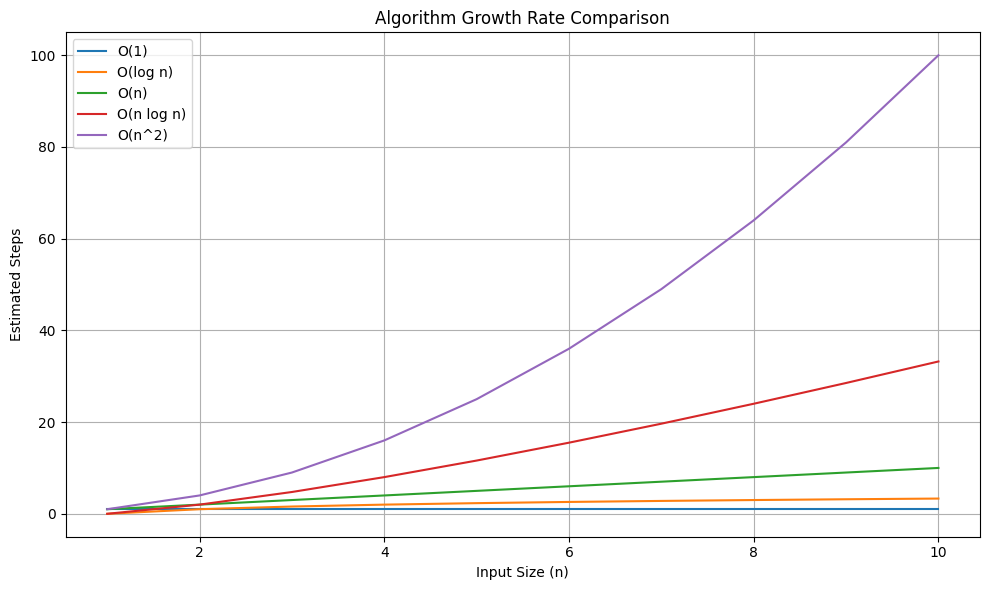

In [4]:
# Activity 1.3 – Visualizing Algorithm Growth
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 11)
growth_curves = {
    'O(1)': np.ones_like(n),
    'O(log n)': np.log2(n),
    'O(n)': n,
    'O(n log n)': n * np.log2(n),
    'O(n^2)': n**2
}

# This plots how different types of algorithms scale with increasing input size, in linear scale.
plt.figure(figsize=(10, 6))
for label, curve in growth_curves.items():
    plt.plot(n, curve, label=label)

plt.title("Algorithm Growth Rate Comparison")
plt.xlabel("Input Size (n)")
plt.ylabel("Estimated Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Expected result:
# O(n²) grows fastest (from the shown functions)
# O(1) stays flat
# O(n log n) grows slower than O(n²) but faster than O(n)


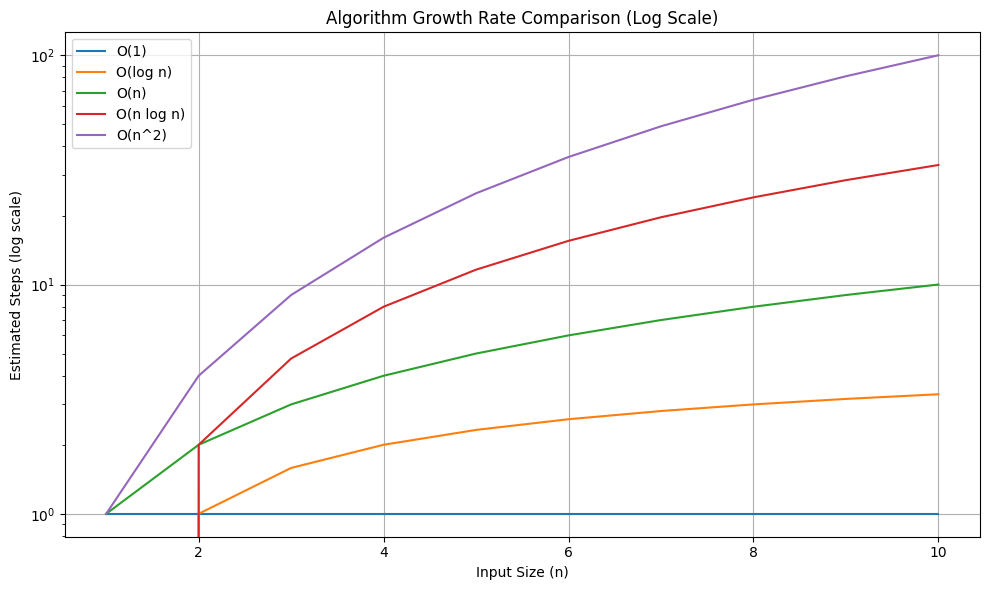

In [5]:
# Zoom in further to visualize better.
plt.figure(figsize=(10, 6))
for label, curve in growth_curves.items():
    plt.plot(n, curve, label=label)

plt.title("Algorithm Growth Rate Comparison (Log Scale)")
plt.xlabel("Input Size (n)")
plt.ylabel("Estimated Steps (log scale)") # Set y-axis to logarithmic scale
plt.legend()
plt.grid(True)
plt.yscale('log') # Set y-axis to logarithmic scale
plt.tight_layout()
plt.show()

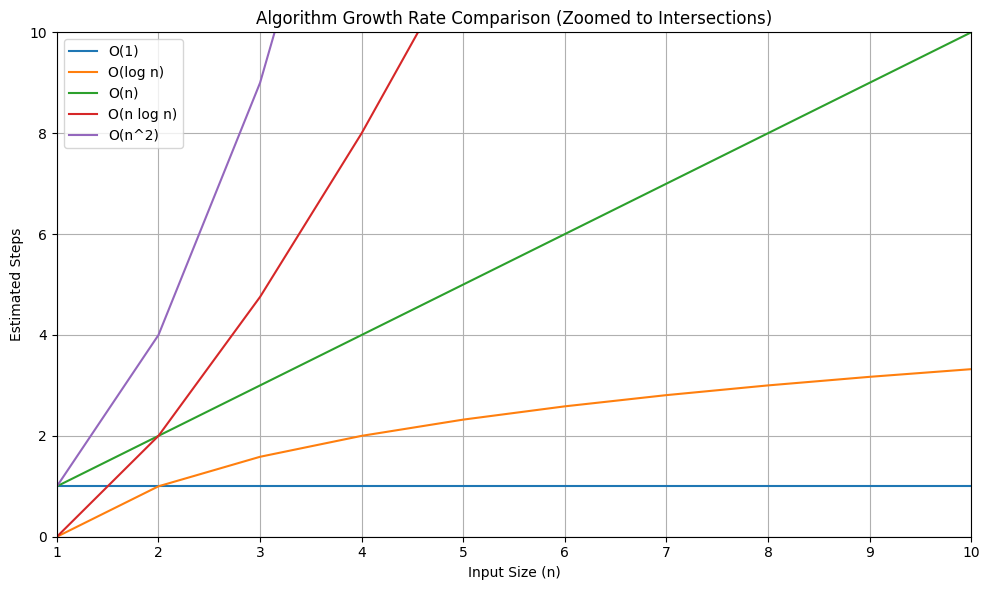

In [6]:
# Algorithm Growth Rate Comparison (Zoomed to Intersections)

plt.figure(figsize=(10, 6))
for label, curve in growth_curves.items():
    plt.plot(n, curve, label=label)

plt.title("Algorithm Growth Rate Comparison (Zoomed to Intersections)")
plt.xlabel("Input Size (n)")
plt.ylabel("Estimated Steps")
plt.legend()
plt.grid(True)
plt.xlim(1, 10) # Set x-axis limits to focus on small input sizes - Adjusted to start from 1
plt.ylim(0, 10) # Set y-axis limits to focus on the initial range of steps
plt.axhline(0, color='gray', linewidth=0.8) # Add horizontal line at y=0
plt.axvline(0, color='gray', linewidth=0.8) # Add vertical line at x=0
plt.tight_layout()
plt.show()

**Reflection Prompt:**

 Which curves intersect?

At n = 1:
- O(1), O(n), and O(n²) intersect at 1 step.
- O(log n) and O(n log n) intersect at 0 steps.

At n = 2:
- O(1) and O(log n) intersect at 1 step.
- O(n) and O(n log n) intersect at 2 steps.


 At what n do inefficient algorithms become unusable?
- The curves mainly intersect at very small input sizes, such as n = 1 and n = 2. There is no fixed n at which an inefficient algorithm becomes unusable because this depends on the computer and the application. However O(n²) becomes impractical much sooner than O(n), O(log n), or O(n log n) as the input grows.





In [7]:
# Activity 1.4 – Linear vs Quadratic Search
# Compares a fast linear search with a slower all-pairs comparison.

def linear_search(data, target):
    for item in data:
        if item == target:
            return True
    return False

def quadratic_search(data):
    for i in range(len(data)):
        for j in range(len(data)):
            if i != j and data[i] == data[j]:
                return True
    return False

In [8]:
# Test the linear_search function
from time import time # Import time module

search_target = 96
values = [61, 24, 81, 70, 30, 92, 96, 84, 84, 97]

start_linear = time()
found_linear = linear_search(values, search_target)
end_linear = time()

print(f"Is {search_target} in values? {found_linear}")
print(f"Linear Search Time: {end_linear - start_linear:.8f} seconds")

# Test the quadratic_search function
start_quadratic = time()
found_quadratic = quadratic_search(values)
end_quadratic = time()


print(f"Quadratic Search Time: {end_quadratic - start_quadratic:.8f} seconds")

# Expected result:
# linear_search() search time is lower than quadratic_search() time.
# quadratic_search() will slow down dramatically with larger datasets.




Is 96 in values? True
Linear Search Time: 0.00011110 seconds
Quadratic Search Time: 0.00012374 seconds


**Reflection Prompt:**
*   Use both with arrays of size 100, 1000 and 10000.


Which becomes unusable first?
- The quadratic search becomes unusable first. Its running time increases much faster because multiplying the input size by 10 can increase its work by approximately 100 times. The linear search remains practical for much larger arrays.





In [9]:
from time import perf_counter

for size in [100, 1000, 10000]:
    values = list(range(size))
    search_target = -1  # Not present, so linear search checks the whole array

    start_linear = perf_counter()
    found_linear = linear_search(values, search_target)
    end_linear = perf_counter()

    start_quadratic = perf_counter()
    found_quadratic = quadratic_search(values)
    end_quadratic = perf_counter()

    print(f"Array size: {size}")
    print(f"Linear search time: {end_linear - start_linear:.8f} seconds")
    print(f"Quadratic search time: {end_quadratic - start_quadratic:.8f} seconds")
    print()

Array size: 100
Linear search time: 0.00000431 seconds
Quadratic search time: 0.00094031 seconds

Array size: 1000
Linear search time: 0.00003694 seconds
Quadratic search time: 0.08061991 seconds

Array size: 10000
Linear search time: 0.00034584 seconds
Quadratic search time: 8.13701574 seconds



In [10]:
# Activity 1.4 – Linear vs Quadratic Search extended

import numpy as np

k = 1000000

values = np.random.randint(0, 1001, k)

search_target = 96

start_linear = time()
found_linear = linear_search(values, search_target)
end_linear = time()

print(f"Is {search_target} in values? {found_linear}")
print(f"Linear Search Time: {end_linear - start_linear:.8f} seconds")

# Test the quadratic_search function
start_quadratic = time()
found_quadratic = quadratic_search(values)
end_quadratic = time()


print(f"Quadratic Search Time: {end_quadratic - start_quadratic:.8f} seconds")

Is 96 in values? True
Linear Search Time: 0.00030184 seconds
Quadratic Search Time: 0.00048828 seconds


In [11]:
# Activity 1.5 – Justifying Complexity by Example
# This code shows how O(n²) becomes worse than O(n) as n increases.

n_values = [10, 100, 1000]
for n in n_values:
    print(f"n={n}, O(n)={n}, O(n^2)={n**2}")

# Expected result:
# O(n²) will balloon quickly
# Good for tabular or graph comparisons


n=10, O(n)=10, O(n^2)=100
n=100, O(n)=100, O(n^2)=10000
n=1000, O(n)=1000, O(n^2)=1000000


**Reflection Prompt:**


*   If your algorithm is O(n²), what's the largest input size you'd tolerate in practice?


I would tolerate an input size of around 1,000 for an O(n²) algorithm. At this size, the algorithm performs about 1,000,000 operations, which is usually manageable. I would avoid using it for much larger inputs because the work increases very quickly. For example, increasing the input to 10,000 produces about 100,000,000 operations.




In [12]:
# Activity 1.6 – Loop Invariant Reasoning
# Related to: Section 1.9 – Building Justification Skills
# Searches linearly for val in search_target.

search_target = 96
values = [61, 24, 81, 70, 30, 92, 96, 84, 84, 97]

def find(values, search_target):
    j = 0
    print(f"Before loop: j = {j}") # Print j before the loop
    while j < len(values):
        print(f"Inside loop (Iteration {j}): Checking values[{j}] = {values[j]}") # Print j and current element inside loop
        if values[j] == search_target:
            print(f"Value found at index {j}") # Indicate value found
            return j
        j += 1
    print(f"After loop: j = {j}. Value not found.") # Print j after loop (if reached)
    return -1

# You can now call the function to see the print statements in action
# Example call:
find(values, search_target) # Returns the index if found, else -1.



Before loop: j = 0
Inside loop (Iteration 0): Checking values[0] = 61
Inside loop (Iteration 1): Checking values[1] = 24
Inside loop (Iteration 2): Checking values[2] = 81
Inside loop (Iteration 3): Checking values[3] = 70
Inside loop (Iteration 4): Checking values[4] = 30
Inside loop (Iteration 5): Checking values[5] = 92
Inside loop (Iteration 6): Checking values[6] = 96
Value found at index 6


6

**Reflection Prompt:**
*   Write down the loop invariant in your own words.

At the start of each loop, all the values before index j have already been checked, and none of them matches the search target. The variable j shows the position that will be checked next.


*   Why does the function work correctly based on it?

The function checks each value in order. If it finds the target, it immediately returns its index. Act 1.6 checks indices 0 through 6 and finds 96 at index 6. If the loop reaches the end without finding the target, every value has been checked, so returning -1 correctly means that the target is not in the list.






In [13]:
# Example of a variable changing in a loop
print("Variable changes in a loop:")
counter = 0
for i in range(5):
    counter += 1  # The value of 'counter' changes in each iteration
    print(f"Iteration {i}: counter = {counter}")

    # Example of a variable not changing in a loop
print("\nVariable does NOT change in a loop:")
constant_value = 100
for i in range(5):
    # The value of 'constant_value' is used but not modified in the loop
    print(f"Iteration {i}: constant_value = {constant_value}")

Variable changes in a loop:
Iteration 0: counter = 1
Iteration 1: counter = 2
Iteration 2: counter = 3
Iteration 3: counter = 4
Iteration 4: counter = 5

Variable does NOT change in a loop:
Iteration 0: constant_value = 100
Iteration 1: constant_value = 100
Iteration 2: constant_value = 100
Iteration 3: constant_value = 100
Iteration 4: constant_value = 100


In [14]:
# Example of a variable not changing in a loop
print("\nVariable does NOT change in a loop:")
constant_value = 100
for i in range(5):
    # The value of 'constant_value' is used but not modified in the loop
    print(f"Iteration {i}: constant_value = {constant_value}")


Variable does NOT change in a loop:
Iteration 0: constant_value = 100
Iteration 1: constant_value = 100
Iteration 2: constant_value = 100
Iteration 3: constant_value = 100
Iteration 4: constant_value = 100


In [15]:
def recursive_sum(n):
    print(f"recursive_sum({n}) called")
    if n == 0:
        print("Base case reached")
        return 0
    return n + recursive_sum(n - 1)

# Function call
result = recursive_sum(5)
print("Final result (recursive):", result)

recursive_sum(5) called
recursive_sum(4) called
recursive_sum(3) called
recursive_sum(2) called
recursive_sum(1) called
recursive_sum(0) called
Base case reached
Final result (recursive): 15


In [16]:
def iterative_sum(n):
    total = 0
    for i in range(n + 1):
        total += i
        print(f"Adding {i}, total so far: {total}")
    return total

# Function call
result = iterative_sum(5)
print("Final result (iterative):", result)

Adding 0, total so far: 0
Adding 1, total so far: 1
Adding 2, total so far: 3
Adding 3, total so far: 6
Adding 4, total so far: 10
Adding 5, total so far: 15
Final result (iterative): 15


In [17]:
# Activity 1.6 – Loop Invariant Reasoning
def find(S, val):
    j = 0
    while j < len(S):
        print(f"Checking S[{j}] = {S[j]}")
        if S[j] == val:
            print(f"Match found at index {j}")
            return j
        j += 1
    print("Value not found")
    return -1

# Function call
S = [2, 4, 6, 8, 10]
val = 6
result = find(S, val)
print("Result (successful case):", result)

# Function call
val = 7
result = find(S, val)
print("Result (unsuccessful case):", result)

Checking S[0] = 2
Checking S[1] = 4
Checking S[2] = 6
Match found at index 2
Result (successful case): 2
Checking S[0] = 2
Checking S[1] = 4
Checking S[2] = 6
Checking S[3] = 8
Checking S[4] = 10
Value not found
Result (unsuccessful case): -1


# Note:
When you are done go to `File` -> `Print` -> `Print PDF` and save the PDF.

You can also save your file to GitHub via: `File` -> `Save a copy in GitHub`